In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 前処理済みのCSVの読み込み
df = pd.read_csv("data/processed/spurs_cleaned_match_data.csv")
df.head()

,season,datetime,home_team,away_team,home_goals,away_goals,spurs_goals,spurs_conceded,spurs_xG,spurs_xGA,spurs_result
0,2022,2022-08-06 14:00:00,Tottenham,Southampton,4,1,4,1,1.617200,0.386546,W
1,2022,2022-08-14 15:30:00,Chelsea,Tottenham,2,2,2,2,1.587080,1.839450,D
2,2022,2022-08-20 11:30:00,Tottenham,Wolverhampton Wanderers,1,0,1,0,1.466080,0.686123,W
3,2022,2022-08-28 15:30:00,Nottingham Forest,Tottenham,0,2,2,0,2.444730,0.801369,W
4,2022,2022-08-31 18:45:00,West Ham,Tottenham,1,1,1,1,0.723285,1.522670,D


In [6]:
# シーズンごとの「合計」得点・失点・xG・xGAを集計
season_stats = df.groupby("season")[["spurs_goals", "spurs_conceded", "spurs_xG", "spurs_xGA"]].sum().reset_index()

In [7]:
# xGとの差分（決定力/守備のパフォーマンス指標）を算出
season_stats["attack_diff"] = season_stats["spurs_goals"] - season_stats["spurs_xG"]
season_stats["defence_diff"] = season_stats["spurs_conceded"] - season_stats["spurs_xGA"]

In [33]:
seasons = season_stats["season"]
goals =  season_stats["spurs_goals"]
xg =  season_stats["spurs_xG"]
conceded =  season_stats["spurs_conceded"]
xga = season_stats["spurs_xGA"]

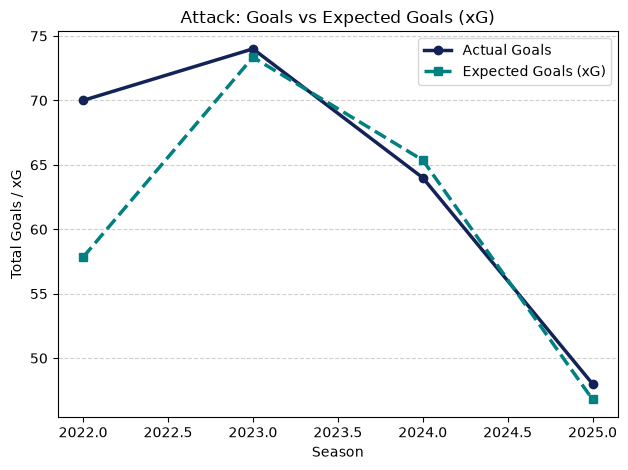

In [34]:
# 攻撃面（総得点　vs xG）　折れ線グラフ
plt.plot(seasons, goals, marker="o", linewidth=2.5, label="Actual Goals", color='#132257')
plt.plot(seasons, xg, marker="s", linewidth=2.5, label="Expected Goals (xG)", color='#008080', linestyle="--")
plt.xlabel("Season")
plt.ylabel("Total Goals / xG")
plt.title("Attack: Goals vs Expected Goals (xG)")

plt.legend(fontsize=10, loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.6)


plt.tight_layout()
plt.show()

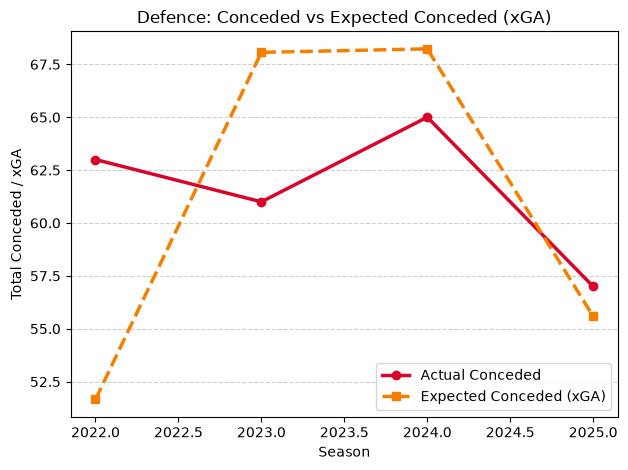

In [35]:
# 守備面（総失点　vs xGA）折れ線グラフ
plt.plot(seasons, conceded, marker="o", linewidth=2.5, label="Actual Conceded", color='#D90429')
plt.plot(seasons, xga, marker="s", linewidth=2.5, label="Expected Conceded (xGA)", color='#F77F00', linestyle="--")
plt.xlabel("Season")
plt.ylabel("Total Conceded / xGA")
plt.title("Defence: Conceded vs Expected Conceded (xGA)")
plt.legend(fontsize=10, loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

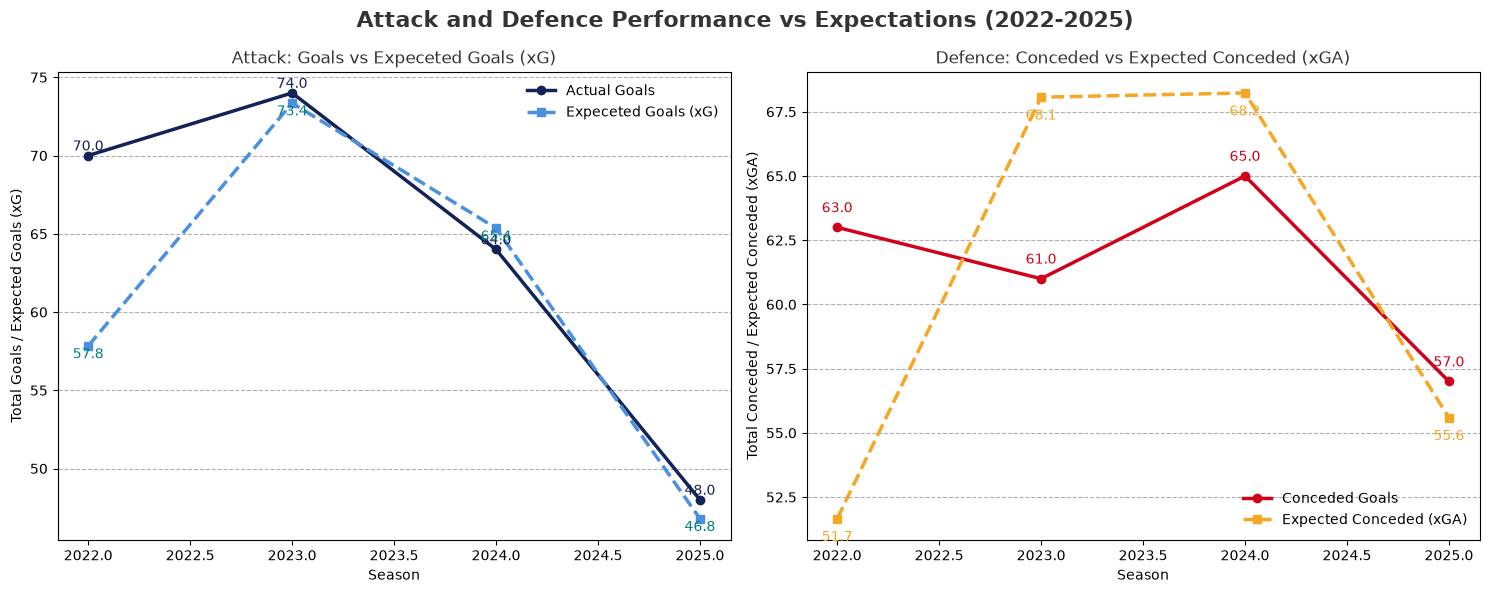

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Attack and Defence Performance vs Expectations (2022-2025)", fontsize=16, fontweight="bold", color="#333333")

axes[0].plot(seasons, goals, marker="o", linewidth=2.5, label="Actual Goals", color='#132257')
axes[0].plot(seasons, xg, marker="s", linewidth=2.5, label="Expeceted Goals (xG)", linestyle="--", color='#4A90E2')
axes[0].set_title("Attack: Goals vs Expeceted Goals (xG)", color="#333333")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Total Goals / Expected Goals (xG)")
axes[0].legend(fontsize=10, frameon=False)
axes[0].grid(axis="y", linestyle="--")

for i in range(len(seasons)):
    axes[0].text(seasons[i], goals[i] + 1, f"{goals[i]:.1f}", ha="center", va="top",color='#132257')
for i in range(len(seasons)):
    axes[0].text(seasons[i], xg[i] - 1, f"{xg[i]:.1f}", ha="center", va="bottom", color='#008080')

axes[1].plot(seasons, conceded, marker="o", linewidth=2.5, label="Conceded Goals", color="#D0021B")
axes[1].plot(seasons, xga, marker="s", linewidth=2.5, label="Expected Conceded (xGA)", linestyle="--", color="#F5A623")
axes[1].set_title("Defence: Conceded vs Expected Conceded (xGA)", color="#333333")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Total Conceded / Expected Conceded (xGA)")
axes[1].legend(fontsize=10, frameon=False)
axes[1].grid(axis="y", linestyle="--")

for i in range(len(seasons)):
    axes[1].text(seasons[i], conceded[i] +1, f"{conceded[i]:.1f}", ha="center", va="top", color="#D0021B")
for i in range(len(seasons)):
    axes[1].text(seasons[i], xga[i] -1, f"{xga[i]:.1f}", ha="center", va="bottom", color="#F5A623")

plt.tight_layout()
plt.show()

In [109]:
results = df.groupby(["season", "spurs_result"]).size().unstack(fill_value=0)

In [115]:
results = results.reindex(columns=["W","D","L"])

In [116]:
results

spurs_result,W,D,L
season,,,
2022,18,6,14
2023,20,6,12
2024,11,5,22
2025,10,11,17


In [138]:
# カラーパレット

gray = ["#A0A0A0", "#7F8C8D"]
dark_grey = ["#2C3E50", "#333333"]
gold = "#C5A059"

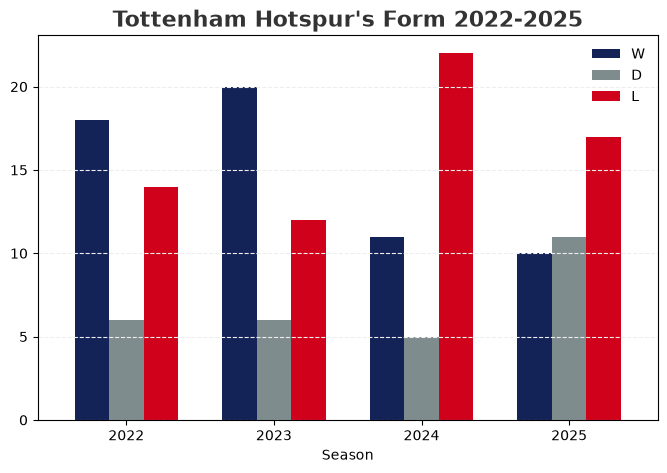

In [149]:
results.plot(kind="bar", figsize=(8, 5), width=0.7, color=["#132257","#7F8C8D", "#D0021B"])
plt.title("Tottenham Hotspur's Form 2022-2025", fontsize=16, fontweight="bold", color="#333333")
plt.xlabel("Season")
plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.grid(axis="y", linestyle="--", color="#EEEEEE")

plt.show()